¿Cuántos datasets se leerán?  


Entrada inválida, se usarán 4 archivos por defecto.
Lista de archivos generada: ['dataset1.txt', 'dataset2.txt', 'dataset3.txt', 'dataset4.txt']
Leyendo.
Se cargó el archivo dataset1.txt con (3250, 4) filas y columnas.
Se cargó el archivo dataset2.txt con (3250, 4) filas y columnas.
Se cargó el archivo dataset3.txt con (5000, 2) filas y columnas.
Se cargó el archivo dataset4.txt con (5000, 2) filas y columnas.



Ingresar el número de columnas a extraer:  


Minimo 2 columnas.
<class 'list'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>



Selecciona 3 números de dataset para las operaciones (1 ― 4):  


Entrada no válida. Se utilizarán por defecto los datasets 1, 2 y 3.
Operaciones realizadas con los datasets: [1, 2, 3]



Seleccione el número de dataset para filtrar (1 a 4):  


Selección inválida. Analizando dataset 1 por defecto.

Se analizaron 2 columna(s) del dataset 1.
Valores filtrados (> 50.0 o < 0):
[np.float64(-0.67), np.float64(-0.35), np.float64(-0.06), np.float64(-0.26), np.float64(-0.6), np.float64(-0.33), np.float64(-0.24), np.float64(-0.61), np.float64(-0.18), np.float64(-0.26), np.float64(-0.47), np.float64(-0.21), np.float64(-0.04)]


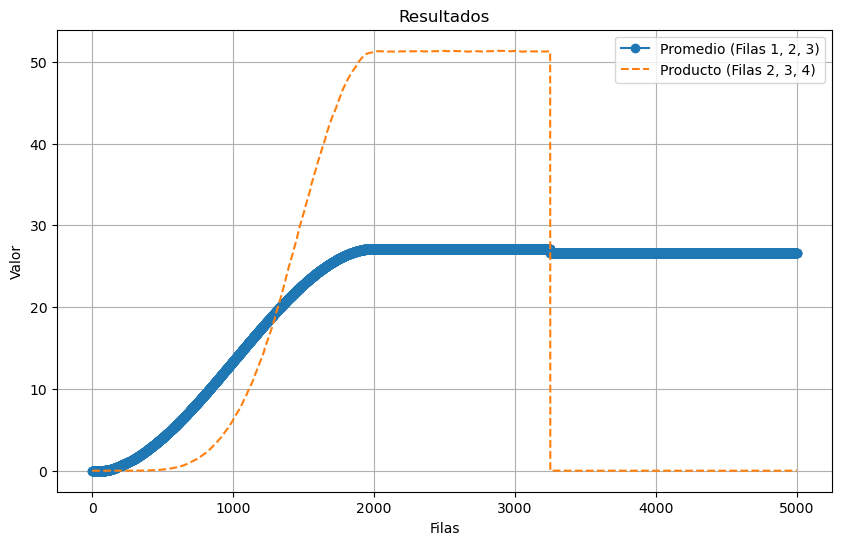

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Leer archivos con ciclo for
try:
    num_files = int(input("¿Cuántos datasets se leerán? "))
    if num_files < 1:
        print("Cantidad no válida, se usará 4 por defecto.")
        num_files = 4
except ValueError:
    print("Entrada inválida, se usarán 4 archivos por defecto.")
    num_files = 4

# Lista de archivos usando un ciclo for
file_list = []
for i in range(1, num_files + 1):
    file_name = f"dataset{i}.txt"
    file_list.append(file_name)

print(f"Lista de archivos generada: {file_list}")

raw_data_storage = []

print("Leyendo.")
for file_name in file_list:
    # Leer los datos con NP
    data = np.loadtxt(file_name)
    raw_data_storage.append(data)
    # shape devuelve indices y elementos correspondientes
    print(f"Se cargó el archivo {file_name} con {data.shape} filas y columnas.")

# Número de columnas a extraer mayor a dos
try:
    num_cols_to_extract = int(input("\nIngresar el número de columnas a extraer: "))
    if num_cols_to_extract < 2:
      # raise utiliza el error en try/except
        raise ValueError
except ValueError:
    num_cols_to_extract = 2
    print("Minimo 2 columnas.")

# Ajustar las dimensiones con zero padding.
# Determinar el número máxico de filas.
max_rows = 0

print(type(raw_data_storage))
for data_set in raw_data_storage:
    print(type(data_set))
    if len(data_set) > max_rows:
        max_rows = len(data_set)

# Almacenar columnas extras necesarias
processed_columns = []

# Procesar y equilibrar cada conjunto de datos
for data_set in raw_data_storage:
    # Columnas necesarias
    extracted = data_set[:, :num_cols_to_extract]

    # Ceros a añadir
    padding_size = max_rows - len(extracted)

    # Añadir ceros usando np.pad
    padded = np.pad(extracted, ((0, padding_size), (0, 0)), mode='constant', constant_values=0)
    processed_columns.append(padded)

# Promedio
# Formula: (c1 + c2 + c3) / 3
try:
    seleccion = input(f"\nSelecciona 3 números de dataset para las operaciones (1 ― {num_files}): ")

    # Convertir la entrada en una lista de enteros y ajustar a índice 0 (restando 1).
    chosen_indices = [int(x) - 1 for x in seleccion.replace(',', ' ').split()]

    # Verificación: Deben ser exactamente 3 y estar dentro del rango disponible
    if len(chosen_indices) != 3 or any(idx < 0 or idx >= num_files for idx in chosen_indices):
        raise ValueError("Selección fuera de rango o cantidad incorrecta.")

except (ValueError, IndexError):
    print(f"Entrada no válida. Se utilizarán por defecto los datasets 1, 2 y 3.")
    chosen_indices = [0, 1, 2]

col_index = 0
avg_result = (processed_columns[chosen_indices[0]][:, col_index] +
              processed_columns[chosen_indices[1]][:, col_index] +
              processed_columns[chosen_indices[2]][:, col_index]) / 3

# Producto elemento por elemento.
prod_result = (processed_columns[chosen_indices[0]][:, col_index] * processed_columns[chosen_indices[1]][:, col_index] * processed_columns[chosen_indices[2]][:, col_index])

print(f"Operaciones realizadas con los datasets: {[i + 1 for i in chosen_indices]}")


try:
    ds_index = int(input(f"\nSeleccione el número de dataset para filtrar (1 a {len(processed_columns)}): ")) - 1

    # Validación de rango
    if ds_index < 0 or ds_index >= len(processed_columns):
        raise IndexError
except (ValueError, IndexError):
    print("Selección inválida. Analizando dataset 1 por defecto.")
    ds_index = 0

threshold = 50.0
filtered_data = []
dataset_to_analyze = processed_columns[ds_index]

# Verificar número de columnas y usarlas
num_cols = dataset_to_analyze.shape[1]
cols_to_process = min(4, num_cols)

for col in range(cols_to_process):
    column_values = dataset_to_analyze[:, col]
    for value in column_values:
        # Lógica: mayor al umbral O negativo
        if value > threshold or value < 0:
            filtered_data.append(value)

print(f"\nSe analizaron {cols_to_process} columna(s) del dataset {ds_index + 1}.")
print(f"Valores filtrados (> {threshold} o < 0):")
print(filtered_data)

# Gráficas
plt.figure(figsize=(10, 6))
plt.plot(avg_result, label='Promedio (Filas 1, 2, 3)', marker='o')
plt.plot(prod_result, label='Producto (Filas 2, 3, 4)', linestyle='--')
plt.title('Resultados')
plt.xlabel('Filas')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.show()